<a href="https://colab.research.google.com/github/arjandhinsa/dr_grading/blob/main/DR_grading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# --- Core ---
import os
import random
import numpy as np
import pandas as pd

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Image handling ---
import cv2
from PIL import Image

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# --- torchvision (models, transforms, pretrained weights) ---
import torchvision
from torchvision import transforms, models

# --- Metrics (QWK, sensitivity/specificity, confusion matrix) ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report, roc_auc_score

# --- Progress bars ---
from tqdm.auto import tqdm

In [13]:
#setting the seed for reproducibility

def set_seed(seed=47):
  random.seed(seed)
  np.random.seed(seed)
  os.environ["PYTHONHASHSEED"] = str(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)          # all GPUs
  torch.backends.cudnn.deterministic = True  # reproducible conv ops
  torch.backends.cudnn.benchmark = False     # trade speed for determinism

set_seed(47)


In [14]:
import kagglehub
kagglehub.login()

In [15]:


# Download latest version
path = kagglehub.competition_download('aptos2019-blindness-detection')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/aptos2019-blindness-detection


In [16]:
print(os.listdir(path))

['test_images', 'test.csv', 'train.csv', 'train_images', 'sample_submission.csv']


In [17]:
df = pd.read_csv(f"{path}/train.csv")
print(df.shape)
print(df.columns.tolist())                    #  ['id_code', 'diagnosis']
print(df['diagnosis'].value_counts().sort_index())
df.head()

(3662, 2)
['id_code', 'diagnosis']
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [18]:
grade_names = {0:"No DR", 1:"Mild", 2:"Moderate", 3:"Severe", 4:"Proliferative"}
counts = df['diagnosis'].value_counts().sort_index()

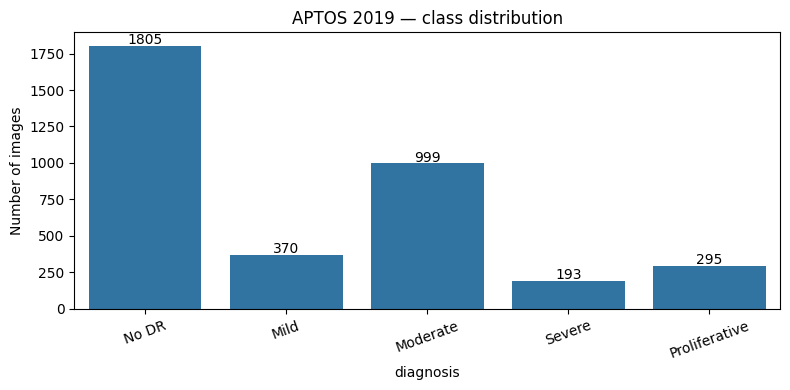

Referable DR (grade >=2): 40.6% of images


In [19]:
#Class distribution

plt.figure(figsize=(8,4))
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(range(5), [grade_names[i] for i in range(5)], rotation=20)
plt.ylabel("Number of images"); plt.title("APTOS 2019 — class distribution")
for i, v in enumerate(counts.values):
    plt.text(i, v+10, str(v), ha='center')
plt.tight_layout(); plt.show()

referable = (df['diagnosis'] >= 2).mean()
print(f"Referable DR (grade >=2): {referable:.1%} of images")


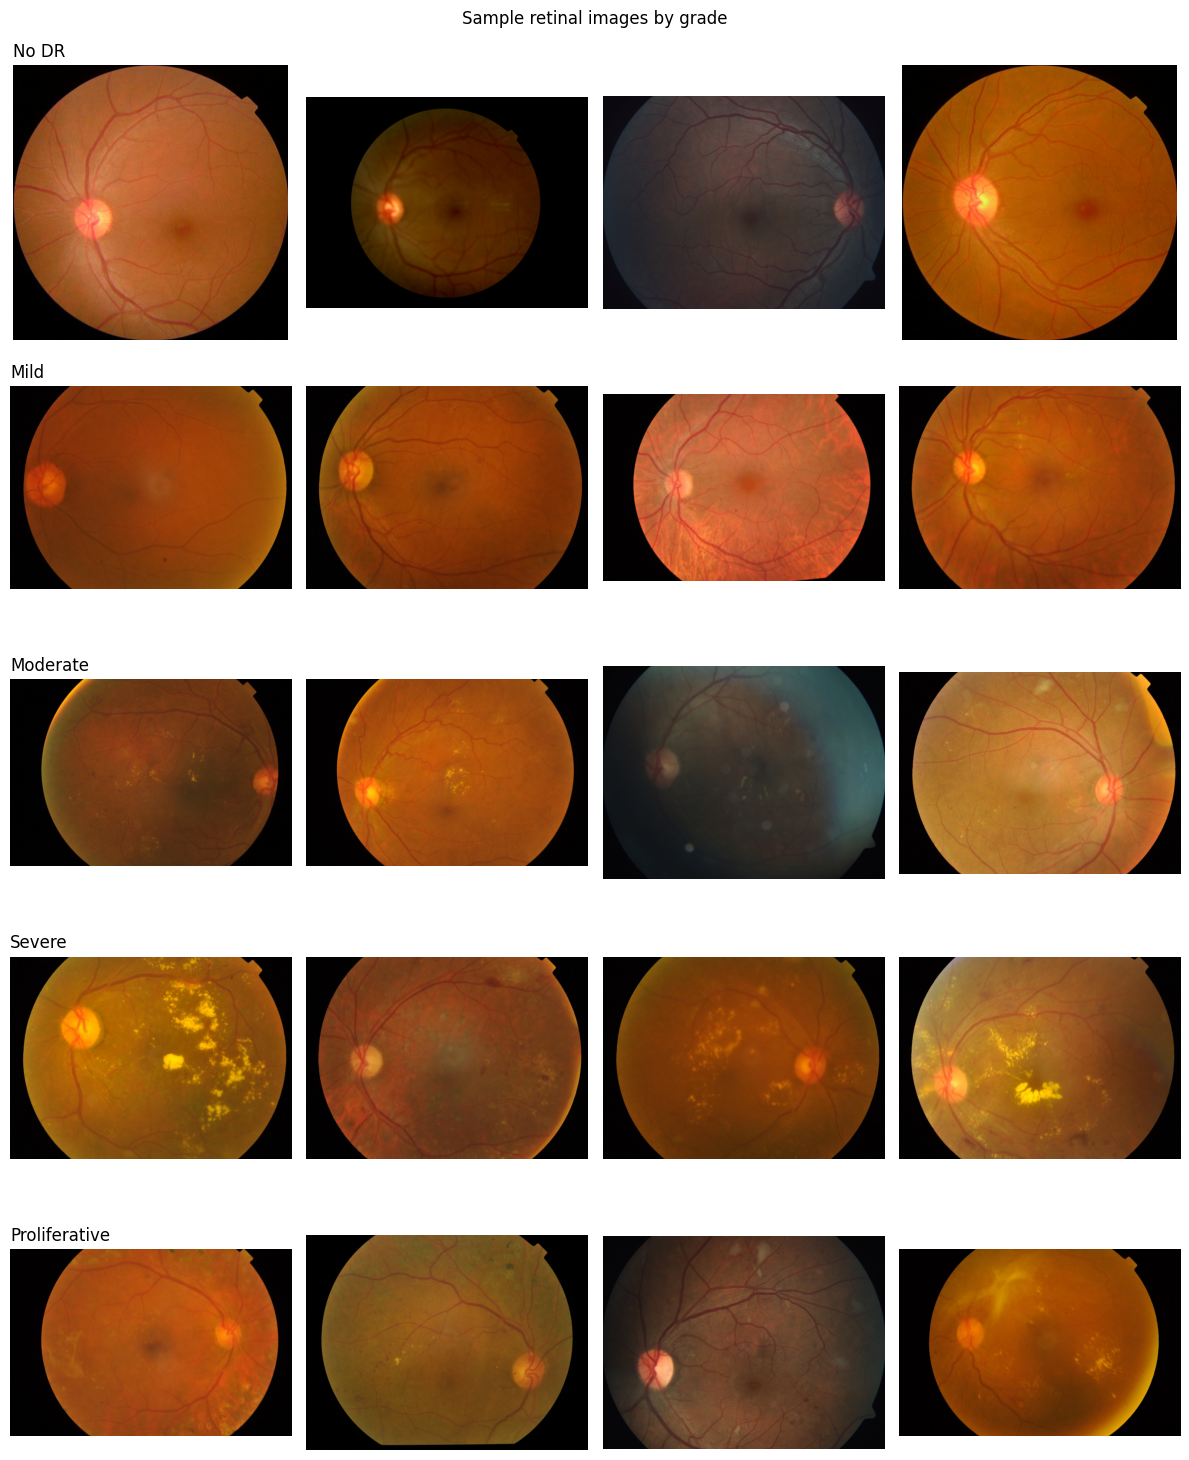

In [20]:
# --- Sample grid: one row per grade, 4 examples each ---
fig, axes = plt.subplots(5, 4, figsize=(12, 15))
for g in range(5):
    ids = df[df['diagnosis']==g]['id_code'].head(4).values
    for j, id_code in enumerate(ids):
        img = cv2.cvtColor(cv2.imread(f"{path}/train_images/{id_code}.png"), cv2.COLOR_BGR2RGB)
        axes[g, j].imshow(img); axes[g, j].axis('off')
    axes[g, 0].set_title(grade_names[g], loc='left')
plt.suptitle("Sample retinal images by grade", y=0.99)
plt.tight_layout(); plt.show()

# RESULT OF EDA


*   In total there are 3662 images
*   1805 of these have no DR
*   370 are mild
*   referable DR (grade ≥2) = 999 + 193 + 295 = 1,487

SO refer 41% don't 59%
(which is close to balanced)


The 5 class problem is where the imbalance lives.


*   No DR (1805) compared to severe (193) - *it's about a 9:1 ratio*
*   Mild (370) and Severe (193) are the starved classes, and so  =the model will struggle to tell adjacent grades apart at he servere end










